In [3]:
import numpy as np
from gensim.models import KeyedVectors
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Load Pre-trained FastText Embeddings
def load_fasttext_embeddings(path):
    return KeyedVectors.load_word2vec_format(path)

# 2. Extract word embeddings for bilingual lexicon
def generate_embeddings(lexicon, en_model, hi_model, num_pairs=1000):
    english_embeddings, hindi_embeddings = [], []

    # Iterate over the word pairs in the lexicon
    for i, (eng_word, hin_word) in enumerate(lexicon[:num_pairs]):
        if eng_word in en_model and hin_word in hi_model:
            eng_vector = en_model[eng_word]
            hin_vector = hi_model[hin_word]
            english_embeddings.append(eng_vector)
            hindi_embeddings.append(hin_vector)

    return np.array(english_embeddings), np.array(hindi_embeddings)

# 3. Procrustes alignment method to learn orthogonal transformation matrix
def procrustes_alignment(X_src, X_tgt):
    X_src = X_src - X_src.mean(0)
    X_tgt = X_tgt - X_tgt.mean(0)

    U, _, Vt = np.linalg.svd(np.dot(X_src.T, X_tgt))
    W = np.dot(U, Vt)
    return W

# 4. Evaluate the precision@k for alignment quality
def precision_at_k(X_src, X_tgt, W, k=1):
    X_src_transformed = np.dot(X_src, W)
    matches = 0

    for i in range(len(X_src_transformed)):
        distances = np.linalg.norm(X_tgt - X_src_transformed[i], axis=1)
        if np.argmin(distances) == i:  # If the closest target word is the correct one
            matches += 1

    return (matches / len(X_src)) * 100


Precision@1: 80.00%


IndexError: index 5 is out of bounds for axis 0 with size 5

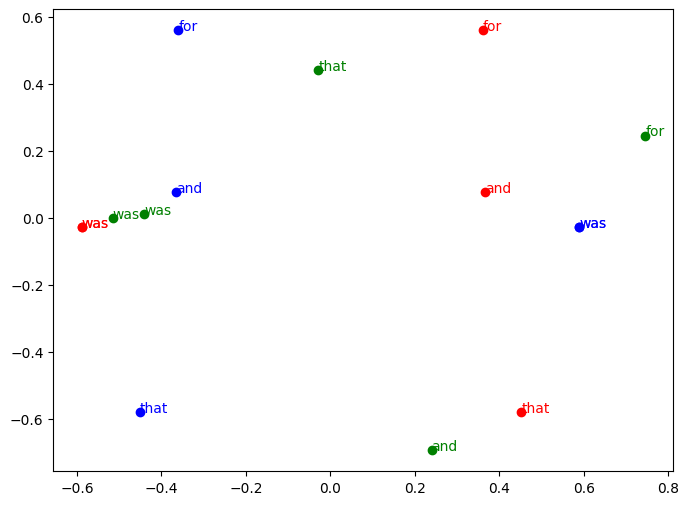

In [4]:

# 5. Visualize before and after alignment
def visualize_embeddings(X_src, X_tgt, W, words, transformed=True):
    pca = PCA(n_components=2)
    X_src_2d = pca.fit_transform(X_src)
    X_tgt_2d = pca.fit_transform(X_tgt)
    if transformed:
        X_src_transformed_2d = pca.fit_transform(np.dot(X_src, W))

    plt.figure(figsize=(8, 6))
    
    plt.scatter(X_src_2d[:, 0], X_src_2d[:, 1], color='blue', label='English Embeddings (Before)')
    plt.scatter(X_tgt_2d[:, 0], X_tgt_2d[:, 1], color='green', label='Hindi Embeddings')
    if transformed:
        plt.scatter(X_src_transformed_2d[:, 0], X_src_transformed_2d[:, 1], color='red', label='English Embeddings (After)')

    # Annotating few points
    for i, word in enumerate(words):
        plt.annotate(word, (X_src_2d[i, 0], X_src_2d[i, 1]), color='blue')
        plt.annotate(word, (X_tgt_2d[i, 0], X_tgt_2d[i, 1]), color='green')
        if transformed:
            plt.annotate(word, (X_src_transformed_2d[i, 0], X_src_transformed_2d[i, 1]), color='red')

    plt.legend()
    plt.title('Embedding Space Before and After Alignment')
    plt.show()

# 6. Main function to run the entire pipeline
def main():
    # Load pre-trained FastText models
    en_model_path = 'aligned_word_vectors\\wiki.en.align.vec'  # English FastText model
    hi_model_path = 'aligned_word_vectors\\wiki.hi.align.vec'  # Hindi FastText model
    en_model = load_fasttext_embeddings(en_model_path)
    hi_model = load_fasttext_embeddings(hi_model_path)

    # Bilingual lexicon (English-Hindi word pairs)
    bilingual_lexicon = []
    with open('english-hindi-bilingual-lexicon.txt', 'r', encoding='utf-8') as f:
        for line in f:
            en_word, hi_word = line.strip().split('\t')
            bilingual_lexicon.append((en_word, hi_word))

    # Step 1: Generate embeddings for word pairs
    X_eng, X_hin = generate_embeddings(bilingual_lexicon, en_model, hi_model, num_pairs=5)

    # Step 2: Perform Procrustes Alignment
    W = procrustes_alignment(X_eng, X_hin)

    # Step 3: Evaluate precision@1
    precision_1 = precision_at_k(X_eng, X_hin, W, k=1)
    print(f"Precision@1: {precision_1:.2f}%")

    # Step 4: Visualize embeddings before and after alignment
    visualize_embeddings(X_eng, X_hin, W, [pair[0] for pair in bilingual_lexicon])

if __name__ == '__main__':
    main()
